<a href="https://colab.research.google.com/github/CatalinaDeras24/CLAVE-G/blob/main/Notebook/Correlacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd

In [19]:
from itertools import combinations

#1- Carga de datos

In [20]:
url="https://raw.githubusercontent.com/CatalinaDeras24/CLAVE-G/refs/heads/main/data/clave_G_correlacion.csv"

In [21]:
df=pd.read_csv(url)

In [22]:
print(df.head())

  cliente_id  edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
0    G-C0001    36                1333                 12            73.69   
1    G-C0002    38                1318                 11           107.75   
2    G-C0003    40                1105                  9            75.72   
3    G-C0004    34                1349                  6            60.43   
4    G-C0005    52                1073                  2            60.52   

   satisfaccion  reclamos  uso_app  tiempo_respuesta  consumo_total  
0          7.34         1       10             18.10         830.56  
1          8.31         1       10             21.55         998.80  
2          5.89         7        7             17.82         563.19  
3          7.41         1        4             24.88         353.01  
4          6.61         3        0             26.30         143.68  


#2-Identificar las variables numéricas del dataset

In [23]:
variables_numericas = df.select_dtypes(include='number').columns

print(variables_numericas)

Index(['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio',
       'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta',
       'consumo_total'],
      dtype='object')


#3- Revisar datos nulos, valores atípicos y consistencia general

In [24]:
df.isnull().sum()

,0
cliente_id,0
edad,0
ingresos_mensuales,0
frecuencia_compra,0
ticket_promedio,1
satisfaccion,1
reclamos,0
uso_app,0
tiempo_respuesta,1
consumo_total,0


In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          251 non-null    object 
 1   edad                251 non-null    int64  
 2   ingresos_mensuales  251 non-null    int64  
 3   frecuencia_compra   251 non-null    int64  
 4   ticket_promedio     250 non-null    float64
 5   satisfaccion        250 non-null    float64
 6   reclamos            251 non-null    int64  
 7   uso_app             251 non-null    int64  
 8   tiempo_respuesta    250 non-null    float64
 9   consumo_total       251 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 19.7+ KB
None


In [27]:
variables_numericas = df.select_dtypes(include='number').columns

for col in variables_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    print(f"{col}: {len(outliers)} valores atípicos")

edad: 0 valores atípicos
ingresos_mensuales: 6 valores atípicos
frecuencia_compra: 3 valores atípicos
ticket_promedio: 2 valores atípicos
satisfaccion: 4 valores atípicos
reclamos: 12 valores atípicos
uso_app: 6 valores atípicos
tiempo_respuesta: 2 valores atípicos
consumo_total: 3 valores atípicos


#4- Calcular la matriz de correlación

In [35]:
matriz_correlacion = df.corr(numeric_only=True)

print(matriz_correlacion)

                        edad  ingresos_mensuales  frecuencia_compra  \
edad                1.000000            0.046354          -0.001589   
ingresos_mensuales  0.046354            1.000000           0.109448   
frecuencia_compra  -0.001589            0.109448           1.000000   
ticket_promedio     0.226557            0.519953           0.066184   
satisfaccion       -0.095200            0.005564           0.241490   
reclamos            0.132463           -0.053131          -0.151309   
uso_app            -0.022369           -0.051252           0.521483   
tiempo_respuesta    0.126786           -0.020264          -0.200154   
consumo_total       0.069585            0.312249           0.876545   

                    ticket_promedio  satisfaccion  reclamos   uso_app  \
edad                       0.226557     -0.095200  0.132463 -0.022369   
ingresos_mensuales         0.519953      0.005564 -0.053131 -0.051252   
frecuencia_compra          0.066184      0.241490 -0.151309  0.521483 

#5 Crear un mapa de calor

In [36]:
import matplotlib.pyplot as plt


In [37]:
import seaborn as sns

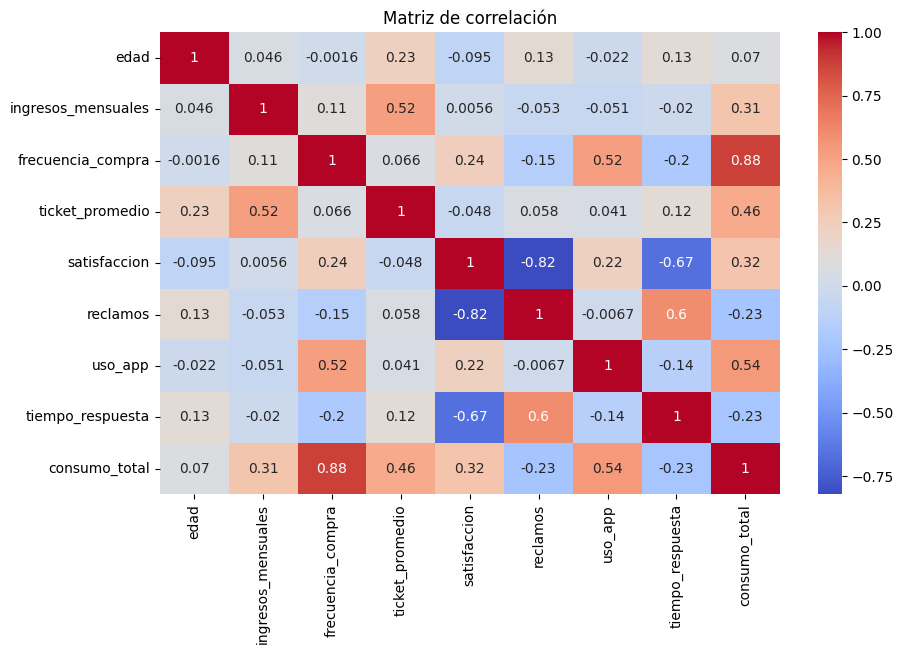

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()